# 79 — FNSPID development reversal-confound test

**Candidate RQ:** distribution shape beyond the mean.

**Objective.** Test whether the development-period coefficient on negative-story
share survives controls for the firm's own price path. The skeptic's alternative
is that negative-share days merely follow a price fall, so the published signal is
short-term reversal or lagged momentum expressed through news.

**Frozen primary estimand.** Estimate the same daily cross-sectional rank
regression as Notebook 71 on a price-complete sample, adding ranks of the firm's
one-session return, five-session return, and 20-session realised volatility. All
controls end at formation open `t`; the outcome starts at `t` and ends at `t+1`.
Average the daily negative-share coefficients and use Newey-West HAC(5) inference.

**Primary success rule.** The fully controlled negative-share coefficient must be
negative with a two-sided HAC p-value below 0.05. The published full-sample
replication and incremental models are audit/descriptive rows, not extra tests.
This is retrospective development evidence, not independent confirmation, and
Notebook 75 remains sealed.

In [1]:
from __future__ import annotations

import hashlib
import json
import subprocess
import sys
from datetime import UTC, datetime
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name == "experiments":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from experiments.lib.conditional_aggregation import (  # noqa: E402
    centred_percentile_rank,
    hac_mean_coefficient,
)
from experiments.lib.panel import (  # noqa: E402
    DEFAULT_PRICE_ZIP,
    load_adjusted_open_prices,
)
from experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402

apply_house_style()
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

OUTPUT = ROOT / "experiments/generated/79_fnspid_development_reversal_confound"
OUTPUT.mkdir(parents=True, exist_ok=True)
SPEC_PATH = (
    ROOT
    / "experiments/specs/conditional_negative_share_price_path_controls_v1_20260812.json"
)
PANEL_PATH = ROOT / "experiments/generated/03_aggregation/firm_day_aggregators.parquet"
NB71_SUMMARY_PATH = (
    ROOT / "experiments/generated/71_conditional_negative_share_transfer/conditional_coefficients.csv"
)
NB75_PATH = ROOT / "experiments/notebooks/75_fnspid_evaluation_beyond_mean_replication.ipynb"
FIGURE_PATH = ROOT / "manuscript/figures/fig_reversal_confound.png"
TABLE_PATH = ROOT / "manuscript/tables/tab_reversal_confound.tex"

BASE_REGRESSORS = ["mean_continuous", "negative_share", "log1p_n"]
PRICE_CONTROLS = ["lagged_return_1", "lagged_return_5", "sigma20"]
OUTCOME = "ar_open_h1"
MIN_NAMES = 10
HAC_LAGS = 5


def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


print(f"repo:   {ROOT}")
print(f"output: {OUTPUT}")
print(f"spec:   {SPEC_PATH.relative_to(ROOT)}")

repo:   /Users/peterprendergast/Documents/Sentiment_Dissertation
output: /Users/peterprendergast/Documents/Sentiment_Dissertation/experiments/generated/79_fnspid_development_reversal_confound
spec:   experiments/specs/conditional_negative_share_price_path_controls_v1_20260812.json


## 1. Frozen specification, input identity, and sealed evaluation audit

In [2]:
spec = json.loads(SPEC_PATH.read_text())
if spec["status"] != "frozen_before_notebook_79_result":
    raise ValueError("unexpected frozen-spec status")

input_audit = pd.DataFrame(
    [
        {
            "input": "fnspid_firm_day_aggregators",
            "path": str(PANEL_PATH.relative_to(ROOT)),
            "expected_sha256": spec["inputs"]["fnspid_firm_day_aggregators"]["sha256"],
            "actual_sha256": sha256(PANEL_PATH),
            "bytes": PANEL_PATH.stat().st_size,
        },
        {
            "input": "fnspid_price_archive",
            "path": str(DEFAULT_PRICE_ZIP),
            "expected_sha256": spec["inputs"]["fnspid_price_archive"]["sha256"],
            "actual_sha256": sha256(DEFAULT_PRICE_ZIP),
            "bytes": DEFAULT_PRICE_ZIP.stat().st_size,
        },
    ]
)
if not input_audit["expected_sha256"].eq(input_audit["actual_sha256"]).all():
    raise ValueError("input hash mismatch")

nb75 = json.loads(NB75_PATH.read_text())
nb75_code = [cell for cell in nb75["cells"] if cell.get("cell_type") == "code"]
seal_audit = {
    "code_cells": len(nb75_code),
    "executed_code_cells": sum(cell.get("execution_count") is not None for cell in nb75_code),
    "output_blocks": sum(len(cell.get("outputs", [])) for cell in nb75_code),
}
if seal_audit["executed_code_cells"] != 0 or seal_audit["output_blocks"] != 0:
    raise RuntimeError("Notebook 75 is no longer sealed")

input_audit.to_csv(OUTPUT / "input_audit.csv", index=False)
(OUTPUT / "evaluation_seal_audit.json").write_text(json.dumps(seal_audit, indent=2) + "\n")
display(input_audit)
display(pd.DataFrame([seal_audit]))

,input,path,expected_sha256,actual_sha256,bytes
0,fnspid_firm_day_aggregators,experiments/generated/03_aggregation/firm_...,1ca1c38109bc06af232119adeff17de66a567174d45703...,1ca1c38109bc06af232119adeff17de66a567174d45703...,55370575
1,fnspid_price_archive,/Users/peterprendergast/Documents/Sentiment_Di...,03da4fce7ebea90d5715ba3501773d410ae663b617027b...,03da4fce7ebea90d5715ba3501773d410ae663b617027b...,589525596


,code_cells,executed_code_cells,output_blocks
0,4,0,0


## 2. Build strictly non-overlapping price-path controls

The formation-session adjusted open is allowed in the controls because it is the
starting price of the forward outcome. Thus `lagged_return_1` ends where
`ar_open_h1` begins. None of the control windows contains the `t` to `t+1`
return being predicted.

In [3]:
panel = pd.read_parquet(PANEL_PATH)
panel["session_date"] = pd.to_datetime(panel["session_date"]).dt.normalize()
development = panel.loc[panel["split"].eq("development")].copy()
development["symbol"] = development["symbol"].astype(str).str.upper()
development["log1p_n"] = np.log1p(development["n"].astype(float))

prices, missing_symbols = load_adjusted_open_prices(
    DEFAULT_PRICE_ZIP,
    set(development["symbol"].unique()),
    start="2010-01-01",
    end="2019-12-31",
)
if missing_symbols:
    raise RuntimeError(f"price archive is missing development symbols: {missing_symbols[:10]}")
prices = prices.sort_values(["symbol", "session_date"], kind="mergesort").copy()
price_groups = prices.groupby("symbol", sort=False)
prices["lagged_return_1"] = price_groups["adjusted_open"].pct_change(fill_method=None)
prices["lagged_return_5"] = prices["adjusted_open"].div(
    price_groups["adjusted_open"].shift(5)
).sub(1.0)
prices["sigma20"] = prices.groupby("symbol", sort=False)["lagged_return_1"].transform(
    lambda values: values.rolling(20, min_periods=20).std(ddof=1)
)

price_features = prices.loc[
    prices["symbol"].ne("SPY"),
    ["symbol", "session_date", *PRICE_CONTROLS],
]
analysis = development.merge(
    price_features,
    on=["symbol", "session_date"],
    how="left",
    validate="m:1",
)

required_complete = [OUTCOME, *BASE_REGRESSORS, *PRICE_CONTROLS]
complete_mask = analysis[required_complete].notna().all(axis=1)
price_complete = analysis.loc[complete_mask].copy()

coverage_rows = []
for column in [OUTCOME, *BASE_REGRESSORS, *PRICE_CONTROLS]:
    available = int(analysis[column].notna().sum())
    coverage_rows.append(
        {
            "field": column,
            "available_rows": available,
            "missing_rows": int(len(analysis) - available),
            "coverage_fraction": available / len(analysis),
        }
    )
coverage = pd.DataFrame(coverage_rows)
sample_audit = pd.DataFrame(
    [
        {
            "sample": "development_full",
            "rows": len(analysis),
            "sessions": analysis["session_date"].nunique(),
            "symbols": analysis["symbol"].nunique(),
            "first_session": analysis["session_date"].min(),
            "last_session": analysis["session_date"].max(),
        },
        {
            "sample": "price_complete",
            "rows": len(price_complete),
            "sessions": price_complete["session_date"].nunique(),
            "symbols": price_complete["symbol"].nunique(),
            "first_session": price_complete["session_date"].min(),
            "last_session": price_complete["session_date"].max(),
        },
    ]
)
coverage.to_csv(OUTPUT / "price_control_coverage.csv", index=False)
sample_audit.to_csv(OUTPUT / "sample_audit.csv", index=False)
display(coverage)
display(sample_audit)

,field,available_rows,missing_rows,coverage_fraction
0,ar_open_h1,512149,4,0.999992
1,mean_continuous,512153,0,1.000000
2,negative_share,512153,0,1.000000
3,log1p_n,512153,0,1.000000
4,lagged_return_1,512142,11,0.999979
5,lagged_return_5,512099,54,0.999895
6,sigma20,511945,208,0.999594


,sample,rows,sessions,symbols,first_session,last_session
0,development_full,512153,2264,570,2011-01-03,2019-12-31
1,price_complete,511941,2264,570,2011-01-03,2019-12-31


## 3. Daily rank regressions

Every variable is ranked separately within session using average ranks for ties,
then centred at zero. Sessions with fewer than ten complete names, a constant
variable, or a rank-deficient design are excluded and counted.

In [4]:
def daily_rank_coefficients(
    frame: pd.DataFrame,
    *,
    regressors: list[str],
) -> tuple[pd.DataFrame, dict[str, int]]:
    required = ["session_date", OUTCOME, *regressors]
    if missing := set(required) - set(frame.columns):
        raise ValueError(f"missing regression columns: {sorted(missing)}")

    use = frame.loc[:, required].copy()
    audit = {
        "dates_total": int(use["session_date"].nunique()),
        "dates_used": 0,
        "dates_below_min_names": 0,
        "dates_constant_variable": 0,
        "dates_rank_deficient": 0,
    }
    rows: list[dict[str, Any]] = []
    complete_columns = [OUTCOME, *regressors]
    for session, day in use.groupby("session_date", sort=True):
        day = day.dropna(subset=complete_columns).copy()
        if len(day) < MIN_NAMES:
            audit["dates_below_min_names"] += 1
            continue
        if any(day[column].nunique() < 2 for column in complete_columns):
            audit["dates_constant_variable"] += 1
            continue

        y = centred_percentile_rank(day[OUTCOME]).to_numpy(dtype=float)
        ranked = np.column_stack(
            [centred_percentile_rank(day[column]).to_numpy(dtype=float) for column in regressors]
        )
        design = np.column_stack([np.ones(len(day), dtype=float), ranked])
        if np.linalg.matrix_rank(design) < design.shape[1]:
            audit["dates_rank_deficient"] += 1
            continue
        beta, *_ = np.linalg.lstsq(design, y, rcond=None)
        residual = y - design @ beta
        tss = float(np.sum((y - y.mean()) ** 2))
        row: dict[str, Any] = {
            "session_date": pd.Timestamp(session),
            "n_names": int(len(day)),
            "intercept": float(beta[0]),
            "r_squared": float(1.0 - np.sum(residual**2) / tss) if tss > 0 else np.nan,
            "condition_number": float(np.linalg.cond(design)),
        }
        row.update({f"beta_{name}": float(value) for name, value in zip(regressors, beta[1:], strict=True)})
        rows.append(row)

    daily = pd.DataFrame(rows).sort_values("session_date", kind="mergesort").reset_index(drop=True)
    audit["dates_used"] = int(len(daily))
    excluded = sum(
        audit[key]
        for key in ("dates_below_min_names", "dates_constant_variable", "dates_rank_deficient")
    )
    if excluded + audit["dates_used"] != audit["dates_total"]:
        raise RuntimeError("daily regression audit does not reconcile")
    return daily, audit


specification_rows = [
    ("published_baseline_full_sample", analysis, BASE_REGRESSORS, "audit reproduction"),
    ("baseline_price_complete_sample", price_complete, BASE_REGRESSORS, "same-sample benchmark"),
    (
        "plus_lagged_return_1",
        price_complete,
        [*BASE_REGRESSORS, "lagged_return_1"],
        "descriptive nested diagnostic",
    ),
    (
        "plus_lagged_returns_1_and_5",
        price_complete,
        [*BASE_REGRESSORS, "lagged_return_1", "lagged_return_5"],
        "descriptive nested diagnostic",
    ),
    (
        "full_price_path_controls",
        price_complete,
        [*BASE_REGRESSORS, *PRICE_CONTROLS],
        "single primary test",
    ),
]

summary_rows = []
exclusion_rows = []
daily_by_spec: dict[str, pd.DataFrame] = {}
for name, sample, regressors, role in specification_rows:
    daily, audit = daily_rank_coefficients(sample, regressors=regressors)
    inference = hac_mean_coefficient(
        daily,
        coefficient_col="beta_negative_share",
        hac_lags=HAC_LAGS,
    )
    summary_rows.append(
        {
            "specification": name,
            "role": role,
            "regressors": ", ".join(regressors),
            "input_rows": len(sample),
            **inference,
        }
    )
    exclusion_rows.append({"specification": name, **audit})
    daily_by_spec[name] = daily
    daily.to_parquet(OUTPUT / f"daily_coefficients_{name}.parquet", index=False)

summary = pd.DataFrame(summary_rows)
exclusion_audit = pd.DataFrame(exclusion_rows)
summary.to_csv(OUTPUT / "conditional_price_control_summary.csv", index=False)
exclusion_audit.to_csv(OUTPUT / "conditional_price_control_exclusion_audit.csv", index=False)
display(
    summary[
        [
            "specification",
            "estimate",
            "se",
            "t",
            "p_two_sided",
            "ci_low",
            "ci_high",
            "n_clusters",
        ]
    ]
)
display(exclusion_audit)

,specification,estimate,se,t,p_two_sided,ci_low,ci_high,n_clusters
0,published_baseline_full_sample,-0.008310,0.002954,-2.813066,0.004907,-0.014100,-0.002520,2264
1,baseline_price_complete_sample,-0.008301,0.002957,-2.807659,0.004990,-0.014096,-0.002506,2264
2,plus_lagged_return_1,-0.009452,0.002908,-3.250476,0.001152,-0.015152,-0.003753,2264
3,plus_lagged_returns_1_and_5,-0.009778,0.002876,-3.400021,0.000674,-0.015414,-0.004141,2264
4,full_price_path_controls,-0.009140,0.002818,-3.244130,0.001178,-0.014663,-0.003618,2264


,specification,dates_total,dates_used,dates_below_min_names,dates_constant_variable,dates_rank_deficient
0,published_baseline_full_sample,2264,2264,0,0,0
1,baseline_price_complete_sample,2264,2264,0,0,0
2,plus_lagged_return_1,2264,2264,0,0,0
3,plus_lagged_returns_1_and_5,2264,2264,0,0,0
4,full_price_path_controls,2264,2264,0,0,0


## 4. Reproduction and primary gate

In [5]:
published_saved = pd.read_csv(NB71_SUMMARY_PATH)
published_saved = published_saved.loc[
    published_saved["source"].eq("FNSPID") & published_saved["block"].eq("development")
].iloc[0]
published_reproduced = summary.loc[
    summary["specification"].eq("published_baseline_full_sample")
].iloc[0]
if not np.isclose(
    float(published_reproduced["estimate"]),
    float(published_saved["estimate"]),
    rtol=0.0,
    atol=1e-12,
):
    raise RuntimeError("Notebook 71 baseline coefficient did not reproduce")

same_sample = summary.loc[
    summary["specification"].eq("baseline_price_complete_sample")
].iloc[0]
primary = summary.loc[summary["specification"].eq("full_price_path_controls")].iloc[0]
primary_pass = bool(primary["estimate"] < 0 and primary["p_two_sided"] < 0.05)
relative_magnitude_change = float(
    (abs(primary["estimate"]) - abs(same_sample["estimate"])) / abs(same_sample["estimate"])
)

full_daily = daily_by_spec["full_price_path_controls"]
full_control_rows = []
for coefficient in [
    "beta_mean_continuous",
    "beta_negative_share",
    "beta_log1p_n",
    "beta_lagged_return_1",
    "beta_lagged_return_5",
    "beta_sigma20",
]:
    full_control_rows.append(
        {
            "coefficient": coefficient,
            **hac_mean_coefficient(full_daily, coefficient_col=coefficient, hac_lags=HAC_LAGS),
        }
    )
full_model_coefficients = pd.DataFrame(full_control_rows)
full_model_coefficients.to_csv(OUTPUT / "full_model_coefficient_summary.csv", index=False)

gate = pd.DataFrame(
    [
        {
            "primary_test": "full_price_path_controls beta_negative_share",
            "expected_direction": "negative",
            "estimate": primary["estimate"],
            "se_hac5": primary["se"],
            "p_two_sided": primary["p_two_sided"],
            "ci_low": primary["ci_low"],
            "ci_high": primary["ci_high"],
            "passes_frozen_gate": primary_pass,
            "same_sample_baseline_estimate": same_sample["estimate"],
            "relative_magnitude_change": relative_magnitude_change,
        }
    ]
)
gate.to_csv(OUTPUT / "primary_gate.csv", index=False)
display(gate)
display(full_model_coefficients)

,primary_test,expected_direction,estimate,se_hac5,p_two_sided,ci_low,ci_high,passes_frozen_gate,same_sample_baseline_estimate,relative_magnitude_change
0,full_price_path_controls beta_negative_share,negative,-0.009140,0.002818,0.001178,-0.014663,-0.003618,True,-0.008301,0.101062


,coefficient,n_clusters,hac_lags,inference,estimate,se,t,p_two_sided,ci_low,ci_high
0,beta_mean_continuous,2264,5,mean_daily_cross_sectional_rank_coefficient_hac,-0.000307,0.002043,-0.150494,0.880375,-0.004311,0.003696
1,beta_negative_share,2264,5,mean_daily_cross_sectional_rank_coefficient_hac,-0.009140,0.002818,-3.244130,0.001178,-0.014663,-0.003618
2,beta_log1p_n,2264,5,mean_daily_cross_sectional_rank_coefficient_hac,0.003152,0.001835,1.717731,0.085846,-0.000445,0.006749
3,beta_lagged_return_1,2264,5,mean_daily_cross_sectional_rank_coefficient_hac,-0.015852,0.002889,-5.487916,0.000000,-0.021514,-0.010191
4,beta_lagged_return_5,2264,5,mean_daily_cross_sectional_rank_coefficient_hac,-0.005134,0.002997,-1.713276,0.086662,-0.011008,0.000739
5,beta_sigma20,2264,5,mean_daily_cross_sectional_rank_coefficient_hac,-0.010086,0.003883,-2.597447,0.009392,-0.017697,-0.002475


## 5. Figure and dissertation-safe table

findfont: Failed to find font weight medium, now using 400.


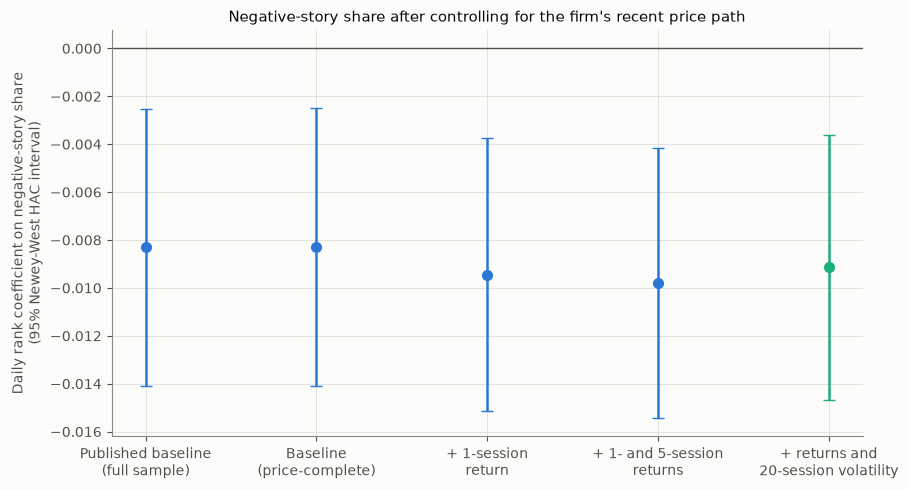

760

In [6]:
labels = {
    "published_baseline_full_sample": "Published baseline\n(full sample)",
    "baseline_price_complete_sample": "Baseline\n(price-complete)",
    "plus_lagged_return_1": "+ 1-session\nreturn",
    "plus_lagged_returns_1_and_5": "+ 1- and 5-session\nreturns",
    "full_price_path_controls": "+ returns and\n20-session volatility",
}
plot_table = summary.copy()
plot_table["label"] = plot_table["specification"].map(labels)
x = np.arange(len(plot_table))
colours = [CATEGORICAL[0]] * (len(plot_table) - 1) + [CATEGORICAL[2]]

fig, ax = plt.subplots(figsize=(9.2, 5.0))
for index, row in plot_table.iterrows():
    ax.errorbar(
        index,
        row["estimate"],
        yerr=[[row["estimate"] - row["ci_low"]], [row["ci_high"] - row["estimate"]]],
        fmt="o",
        color=colours[index],
        capsize=4,
        markersize=7,
        linewidth=1.8,
    )
ax.axhline(0.0, color=INK["reference"], linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(plot_table["label"])
ax.set_ylabel("Daily rank coefficient on negative-story share\n(95% Newey-West HAC interval)")
ax.set_title("Negative-story share after controlling for the firm's recent price path")
fig.tight_layout()
fig.savefig(OUTPUT / "conditional_negative_share_price_controls.png", dpi=200, bbox_inches="tight")
FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_PATH, dpi=300, bbox_inches="tight")
plt.show()

table_labels = {
    "published_baseline_full_sample": "Published baseline (full sample)",
    "baseline_price_complete_sample": "Baseline (price-complete)",
    "plus_lagged_return_1": "+ lagged one-session return",
    "plus_lagged_returns_1_and_5": "+ lagged one- and five-session returns",
    "full_price_path_controls": "+ returns and 20-session volatility",
}
latex_lines = [
    r"\setlength{\tabcolsep}{5pt}",
    r"\begin{tabular}{@{}lrrrrr@{}}",
    r"\toprule",
    r"Specification & $\hat\beta_{neg}$ & HAC SE & 95\% CI & $p$ & Sessions \\",
    r"\midrule",
]
for _, row in summary.iterrows():
    latex_lines.append(
        f"{table_labels[row['specification']]} & "
        f"{row['estimate']:.5f} & {row['se']:.5f} & "
        f"[{row['ci_low']:.5f}, {row['ci_high']:.5f}] & "
        f"{row['p_two_sided']:.4f} & {int(row['n_clusters']):,} \\\\"
    )
latex_lines.extend(
    [
        r"\bottomrule",
        r"\end{tabular}",
        "% Generated by experiments/79_fnspid_development_reversal_confound.ipynb.",
        "% All price controls end at formation open t; ar_open_h1 runs from t to t+1.",
    ]
)
TABLE_PATH.parent.mkdir(parents=True, exist_ok=True)
TABLE_PATH.write_text("\n".join(latex_lines) + "\n")

## 6. Result boundary and machine-readable provenance

In [7]:
interpretation = (
    "The frozen reversal-confound test passes: negative-story share remains negative "
    "and statistically distinguishable from zero after the three price-path controls."
    if primary_pass
    else "The frozen reversal-confound test does not pass: the fully controlled coefficient "
    "does not satisfy both the negative-direction and two-sided 5% conditions."
)
boundary = (
    "This supports information beyond this observed price path in the development sample. "
    "It does not establish causality, remove every omitted variable, or supply independent confirmation."
)
display(
    Markdown(
        f"**Primary result:** $\\hat{{\\beta}}={primary['estimate']:.4f}$, "
        f"95% HAC CI [{primary['ci_low']:.4f}, {primary['ci_high']:.4f}], "
        f"$p={primary['p_two_sided']:.4f}$. {interpretation} {boundary}"
    )
)

result = {
    "status": "completed",
    "executed_at_utc": datetime.now(UTC).isoformat(),
    "candidate_rq": spec["experiment"]["candidate_rq"],
    "population": {
        "development_rows": int(len(analysis)),
        "price_complete_rows": int(len(price_complete)),
        "sessions": int(price_complete["session_date"].nunique()),
        "symbols": int(price_complete["symbol"].nunique()),
    },
    "published_baseline_reproduced": True,
    "same_sample_baseline": {
        "estimate": float(same_sample["estimate"]),
        "se": float(same_sample["se"]),
        "p_two_sided": float(same_sample["p_two_sided"]),
        "ci_low": float(same_sample["ci_low"]),
        "ci_high": float(same_sample["ci_high"]),
    },
    "primary": {
        "specification": "full_price_path_controls",
        "estimate": float(primary["estimate"]),
        "se": float(primary["se"]),
        "p_two_sided": float(primary["p_two_sided"]),
        "ci_low": float(primary["ci_low"]),
        "ci_high": float(primary["ci_high"]),
        "n_clusters": int(primary["n_clusters"]),
        "passes_frozen_gate": primary_pass,
        "relative_magnitude_change_vs_same_sample_baseline": relative_magnitude_change,
    },
    "interpretation": interpretation,
    "claim_boundary": boundary,
    "evaluation_notebook_75_seal": seal_audit,
}
(OUTPUT / "result.json").write_text(json.dumps(result, indent=2) + "\n")

output_paths = sorted(
    path
    for path in OUTPUT.iterdir()
    if path.is_file() and path.name != "manifest.json"
)
manifest = {
    "notebook": "experiments/79_fnspid_development_reversal_confound.ipynb",
    "source": "experiments/79_fnspid_development_reversal_confound.py",
    "spec": str(SPEC_PATH.relative_to(ROOT)),
    "declared_spec": str(SPEC_PATH.relative_to(ROOT)),
    "spec_sha256": sha256(SPEC_PATH),
    "git_commit_at_execution": subprocess.check_output(
        ["git", "rev-parse", "HEAD"], cwd=ROOT, text=True
    ).strip(),
    "executed_at_utc": result["executed_at_utc"],
    "inputs": input_audit.to_dict(orient="records"),
    "outputs": [
        {
            "path": str(path.relative_to(ROOT)),
            "sha256": sha256(path),
            "bytes": path.stat().st_size,
        }
        for path in output_paths
    ],
    "aggregate_dissertation_artifacts": [
        {
            "path": str(FIGURE_PATH.relative_to(ROOT)),
            "sha256": sha256(FIGURE_PATH),
            "bytes": FIGURE_PATH.stat().st_size,
        },
        {
            "path": str(TABLE_PATH.relative_to(ROOT)),
            "sha256": sha256(TABLE_PATH),
            "bytes": TABLE_PATH.stat().st_size,
        },
    ],
    "evaluation_notebook_75_seal": seal_audit,
}
(OUTPUT / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")

print(json.dumps(result, indent=2))
print(f"manifest: {OUTPUT / 'manifest.json'}")
print(f"figure:   {FIGURE_PATH.relative_to(ROOT)}")
print(f"table:    {TABLE_PATH.relative_to(ROOT)}")

**Primary result:** $\hat{\beta}=-0.0091$, 95% HAC CI [-0.0147, -0.0036], $p=0.0012$. The frozen reversal-confound test passes: negative-story share remains negative and statistically distinguishable from zero after the three price-path controls. This supports information beyond this observed price path in the development sample. It does not establish causality, remove every omitted variable, or supply independent confirmation.

{
  "status": "completed",
  "executed_at_utc": "2026-08-12T20:35:15.259799+00:00",
  "candidate_rq": "distribution_shape_beyond_the_mean",
  "population": {
    "development_rows": 512153,
    "price_complete_rows": 511941,
    "sessions": 2264,
    "symbols": 570
  },
  "published_baseline_reproduced": true,
  "same_sample_baseline": {
    "estimate": -0.00830143048136616,
    "se": 0.002956709232127447,
    "p_two_sided": 0.004990308015770633,
    "ci_low": -0.014096474089093036,
    "ci_high": -0.002506386873639286
  },
  "primary": {
    "specification": "full_price_path_controls",
    "estimate": -0.009140391546921745,
    "se": 0.0028175167102856,
    "p_two_sided": 0.0011780980864329784,
    "ci_low": -0.014662622824921295,
    "ci_high": -0.0036181602689221957,
    "n_clusters": 2264,
    "passes_frozen_gate": true,
    "relative_magnitude_change_vs_same_sample_baseline": 0.10106222866513931
  },
  "interpretation": "The frozen reversal-confound test passes: negative-story sha

## 7. Next step

Carry the frozen result into the dissertation write-up exactly as observed. If the
gate passes, the defensible wording is that the development-sample association is
incremental to mean sentiment, story count, lagged one- and five-session returns,
and trailing volatility. If it fails, narrow the headline claim before opening the
sealed 2020–2023 replication. Do not tune the lags, window, sample, or transform.